<a href="https://colab.research.google.com/github/chavezgranados/Quantitative-Methods/blob/main/notebooks/cuaderno2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div align="center">

<font face="gotham" color="#1B5E20"> Unidad de Posgrado de la Facultad de Economía </font>

<img src="https://yachay.digital/wp-content/uploads/2021/03/uncp.png" width="120">

<font face="gotham" color="#1B5E20"> **Curso: Métodos Cuantitativos Aplicados a la Investigación** </font>

<hr width="50%" color="#C9A227">

<font face="gotham" color="#1B5E20"> Maestría en Planificación y Proyectos de Inversión </font>

<font face="gotham" color="#1B5E20"> `Luis Chávez` </font>

<font face="gotham" color="#1B5E20"> 2026 </font>

# <font face="gotham" color="#E3B10D"> **Tópico: data cleaning**</font>

In [ ]:
# Preámbulo
# ==============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats.mstats import winsorize

In [ ]:
url = "https://raw.githubusercontent.com/chavezgranados/Quantitative-Methods/main/datasets/01clientes.xlsx"
datos = pd.read_excel(url)
datos

,fecha,NumeroOperacion,CodigoCliente,Estado,Riesgo,Agencia_Venta,Plazo_Dias,Tasa_Interes,Saldo_Prom_Periodo,Saldo_Corte,...,Transferencia,Provision_Req,Provision,Dealers,Gastos_Inversion,Gastos_Indirectos,Transferencia_Total,Desembolso_Neto,EstadoCivil,Sexo
0,2023-01-31,1,1,Vigentes,BAJO,AG. CHIMBOTE,2227,10.60,13661.19,16000.00,...,-111.503534,71.32,160.00,0.000000,1.934347,51.852710,-110.197603,7220.21,1,0
1,2023-02-28,1,1,Vigentes,BAJO,AG. CHIMBOTE,2227,10.60,16000.00,16000.00,...,-117.910000,0.00,160.00,0.000000,0.916893,7.958110,-116.730925,0.00,1,1
2,2023-03-31,1,1,Vigentes,BAJO,AG. CHIMBOTE,2227,10.60,15869.68,15844.62,...,-129.530000,-1.55,158.45,0.000000,0.597064,7.648716,-128.236721,0.00,2,0
3,2023-04-30,1,1,Vigentes,MUY BAJO,AG. CHIMBOTE,2227,10.60,15710.42,15689.77,...,-124.080000,-1.55,156.90,0.000000,2.269683,7.675703,-122.840849,0.00,0,1
4,2023-05-31,1,1,Vigentes,MUY BAJO,AG. CHIMBOTE,2227,10.60,15564.93,15528.52,...,-127.040000,-1.61,155.29,0.000000,0.911305,6.753662,-125.772513,0.00,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38491,2024-03-31,2036,2036,Vigentes,BAJO,AG. CARSA HUANUCO,2235,12.08,98813.14,98298.70,...,-806.520000,-12.26,982.99,0.000000,0.907032,60.917240,-798.496771,0.00,3,0
38492,2024-04-30,2036,2036,Vigentes,BAJO,AG. HUANCAYO,2235,12.08,107000.00,107000.00,...,-688.438428,87.01,1070.00,-150.449483,0.912238,89.719220,-681.554044,6939.73,2,0
38493,2024-05-31,2036,2036,Vigentes,BAJO,OF. PRINCIPAL,2235,12.08,107000.00,107000.00,...,-784.200000,0.00,1070.00,0.000000,0.124627,54.021720,-776.357980,0.00,2,0
38494,2024-06-30,2036,2036,Vigentes,BAJO,OF. PRINCIPAL,2235,12.08,106607.12,106158.12,...,-685.910000,-8.42,1061.58,0.000000,0.578882,57.603060,-679.079790,0.00,1,0


## **1. Missing values**

> **Se inspecciona la estructura del conjunto de datos:**

In [ ]:
datos.info() #nota: causa ruido los tipos "object"

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38496 entries, 0 to 38495
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   fecha                 38496 non-null  datetime64[ns]
 1   NumeroOperacion       38496 non-null  int64         
 2   CodigoCliente         38496 non-null  int64         
 3   Estado                38496 non-null  object        
 4   Riesgo                38124 non-null  object        
 5   Agencia_Venta         38459 non-null  object        
 6   Plazo_Dias            38496 non-null  int64         
 7   Tasa_Interes          38496 non-null  float64       
 8   Saldo_Prom_Periodo    38496 non-null  float64       
 9   Saldo_Corte           38496 non-null  float64       
 10  Ingresos_Financieros  38496 non-null  float64       
 11  Transferencia         38496 non-null  float64       
 12  Provision_Req         38496 non-null  float64       
 13  Provision       

> **Se evalúa las variables tipo `object`:**

In [ ]:
datos["Estado"].unique()

array(['Vigentes', '(en blanco)', 'Vencidos', 'Refinanciados'],
      dtype=object)

In [ ]:
datos["Riesgo"].unique()

array(['BAJO', 'MUY BAJO', '(en blanco)', 'HIPER BAJO', 'MEDIO',
       'NO DESEADO', 'ALTO', nan], dtype=object)

In [ ]:
datos["Agencia_Venta"].unique()

array(['AG. CHIMBOTE', 'OF. PRINCIPAL', 'AG. ICA', '(en blanco)',
       'AG. CARSA HUANUCO', 'AG. TRUJILLO', 'AG. PIURA', 'AG. CHICLAYO',
       'AG. SAN JUAN DE MIRAFLORES', 'AG. HUARAZ', 'AG. COLONIAL',
       'AG. COMAS', 'AG. EMANCIPACION', 'AG. RISSO', 'AG. HIGUERETA',
       'AG. CHACARILLA', 'AG. CARSA PUCALLPA', 'AG. SAN MIGUEL',
       'AG. MIRAFLORES', 'AG. CAJAMARCA', 'AG. ZARATE', 'AG. SANTA ANITA',
       'AG. CARSA LA MERCED', 'AG. VILLA EL SALVADOR', 'AG. HUANCAYO',
       'AG. TACNA', 'AG. CHORRILLOS', 'AG. CARSA ICA', 'AG. FIORI',
       'AG. CARSA HUACHO', 'AG. VILLA MARIA DEL TRIUNFO', 'AG. TUMBES',
       'AG. AREQUIPA', 'AG. CARSA TARAPOTO', 'AG. IQUITOS', 'AG. MINKA',
       'AG. CARSA JAEN', 'AG. PUNO', 'AG. CUSCO', 'AG. EL PORVENIR', nan,
       'AG. PUENTE PIEDRA', 'AG. JESUS MARIA', 'AG. SAN MARCOS',
       'AG. SAN HILARION', 'AG. LA MOLINA', 'AG. MORELLI', 'AG. CAPON',
       'AG. SAN FELIPE', 'AG. SUCRE', 'AG. GAMARRA', 'AG. SALAVERRY',
       'AG. MONTERR

> **Se evalúa las cantidad de valores `nan` de las variables tipo `object`:**

In [ ]:
datos["Estado"].value_counts(dropna=False)

,count
Estado,
Vigentes,31561
(en blanco),5781
Vencidos,961
Refinanciados,193


> **Solución: convertir `(en blanco)` a `nan`:**

In [ ]:
datos = datos.replace("(en blanco)", np.nan)

In [ ]:
datos = datos.dropna(subset=["Estado"])  # Estado es la variable clave para borrar filas
# datos = datos.dropna()  # elimina toda la fila si existe un nan  en alguna celda

In [ ]:
datos

,fecha,NumeroOperacion,CodigoCliente,Estado,Riesgo,Agencia_Venta,Plazo_Dias,Tasa_Interes,Saldo_Prom_Periodo,Saldo_Corte,...,Transferencia,Provision_Req,Provision,Dealers,Gastos_Inversion,Gastos_Indirectos,Transferencia_Total,Desembolso_Neto,EstadoCivil,Sexo
0,2023-01-31,1,1,Vigentes,BAJO,AG. CHIMBOTE,2227,10.60,13661.19,16000.00,...,-111.503534,71.32,160.00,0.000000,1.934347,51.852710,-110.197603,7220.21,1,0
1,2023-02-28,1,1,Vigentes,BAJO,AG. CHIMBOTE,2227,10.60,16000.00,16000.00,...,-117.910000,0.00,160.00,0.000000,0.916893,7.958110,-116.730925,0.00,1,1
2,2023-03-31,1,1,Vigentes,BAJO,AG. CHIMBOTE,2227,10.60,15869.68,15844.62,...,-129.530000,-1.55,158.45,0.000000,0.597064,7.648716,-128.236721,0.00,2,0
3,2023-04-30,1,1,Vigentes,MUY BAJO,AG. CHIMBOTE,2227,10.60,15710.42,15689.77,...,-124.080000,-1.55,156.90,0.000000,2.269683,7.675703,-122.840849,0.00,0,1
4,2023-05-31,1,1,Vigentes,MUY BAJO,AG. CHIMBOTE,2227,10.60,15564.93,15528.52,...,-127.040000,-1.61,155.29,0.000000,0.911305,6.753662,-125.772513,0.00,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38491,2024-03-31,2036,2036,Vigentes,BAJO,AG. CARSA HUANUCO,2235,12.08,98813.14,98298.70,...,-806.520000,-12.26,982.99,0.000000,0.907032,60.917240,-798.496771,0.00,3,0
38492,2024-04-30,2036,2036,Vigentes,BAJO,AG. HUANCAYO,2235,12.08,107000.00,107000.00,...,-688.438428,87.01,1070.00,-150.449483,0.912238,89.719220,-681.554044,6939.73,2,0
38493,2024-05-31,2036,2036,Vigentes,BAJO,OF. PRINCIPAL,2235,12.08,107000.00,107000.00,...,-784.200000,0.00,1070.00,0.000000,0.124627,54.021720,-776.357980,0.00,2,0
38494,2024-06-30,2036,2036,Vigentes,BAJO,OF. PRINCIPAL,2235,12.08,106607.12,106158.12,...,-685.910000,-8.42,1061.58,0.000000,0.578882,57.603060,-679.079790,0.00,1,0


> **Se verifica `nan` en todo el dataset:**

In [ ]:
datos.isna().sum() #NULL está leyendo como nan

,0
fecha,0
NumeroOperacion,0
CodigoCliente,0
Estado,0
Riesgo,372
Agencia_Venta,37
Plazo_Dias,0
Tasa_Interes,0
Saldo_Prom_Periodo,0
Saldo_Corte,0


Lista de caracteres que pandas lee como `nan`:
NaN, nan, NAN, NA, N/A, #N/A, NULL, null, None y \<NA\>.

> **Imputación de `nan`:**



In [ ]:
# Numéricos: con la media
datos["Ingresos_Financieros"] = datos["Ingresos_Financieros"].fillna(datos["Ingresos_Financieros"].mean())

In [ ]:
# Numéricos: con la mediana
datos["Ingresos_Financieros"] = datos["Ingresos_Financieros"].fillna(datos["Ingresos_Financieros"].median())

In [ ]:
# Categóricas: con la moda
datos["Agencia_Venta"] = datos["Agencia_Venta"].fillna(datos["Agencia_Venta"].mode()[0])

## **2. Outliers**



> **Se identifica valores mínimos y máximos raros (por ejemplo: 99999):**

In [ ]:
datos.describe()

,fecha,NumeroOperacion,CodigoCliente,Plazo_Dias,Tasa_Interes,Saldo_Prom_Periodo,Saldo_Corte,Ingresos_Financieros,Transferencia,Provision_Req,Provision,Dealers,Gastos_Inversion,Gastos_Indirectos,Transferencia_Total,Desembolso_Neto,EstadoCivil,Sexo
count,32715,32715.000000,32715.000000,32715.000000,32715.000000,32715.000000,32715.000000,32715.000000,32715.000000,32715.000000,32715.000000,32715.000000,32715.000000,32715.000000,32715.000000,32715.000000,32715.000000,32715.000000
mean,2023-10-08 05:01:12.297111296,1036.953997,1036.953997,2050.263396,13.104007,53445.854851,54231.916754,508.587952,-420.050650,129.643643,1331.612813,-14.498368,0.965317,25.760829,-409.445553,2935.561773,1.509827,0.498731
min,2023-01-31 00:00:00,1.000000,1.000000,203.000000,9.000000,0.000000,0.000000,-5356.560000,-1298.520000,-112874.670000,0.000000,-1900.337762,-3.773554,0.000000,-1285.588431,0.000000,0.000000,0.000000
25%,2023-05-31 00:00:00,530.000000,530.000000,1862.000000,11.100000,33685.375000,34966.635000,331.395000,-534.020000,-7.850000,370.785000,0.000000,0.597064,6.464274,-526.651366,0.000000,1.000000,0.000000
50%,2023-09-30 00:00:00,1050.000000,1050.000000,2214.000000,11.780000,54324.170000,55195.740000,540.270000,-432.060000,-5.590000,574.470000,0.000000,0.916893,11.623450,-423.299525,0.000000,2.000000,0.000000
75%,2024-02-29 00:00:00,1547.000000,1547.000000,2231.000000,13.750000,68275.950000,69150.000000,666.935000,-269.120000,0.000000,737.015000,0.000000,1.934347,34.214425,-256.447966,0.000000,3.000000,1.000000
max,2024-07-31 00:00:00,2036.000000,2036.000000,11097.000000,54.450000,160000.000000,160000.000000,15242.530000,0.000000,112769.040000,114795.720000,0.000000,2.367383,1464.213000,707.464397,144770.000000,3.000000,1.000000
std,NaN,590.243575,590.243575,675.728410,3.647372,28585.202167,29158.923948,339.926518,221.078417,2119.884585,5242.975717,100.695882,1.284528,42.742983,221.619606,12591.888910,1.119634,0.500006


> **Identificación por regla del IQR (Tukey)**

In [ ]:
for col in datos.select_dtypes(include="number"):

    Q1 = datos[col].quantile(0.25)
    Q3 = datos[col].quantile(0.75)

    IQR = Q3 - Q1

    LI = Q1 - 1.5 * IQR
    LS = Q3 + 1.5 * IQR

    n = ((datos[col] < LI) | (datos[col] > LS)).sum()

    print(f"{col}: {n} outliers")

NumeroOperacion: 0 outliers
CodigoCliente: 0 outliers
Plazo_Dias: 5723 outliers
Tasa_Interes: 1842 outliers
Saldo_Prom_Periodo: 764 outliers
Saldo_Corte: 811 outliers
Ingresos_Financieros: 641 outliers
Transferencia: 788 outliers
Provision_Req: 6014 outliers
Provision: 2509 outliers
Dealers: 1022 outliers
Gastos_Inversion: 1580 outliers
Gastos_Indirectos: 1723 outliers
Transferencia_Total: 694 outliers
Desembolso_Neto: 3057 outliers
EstadoCivil: 0 outliers
Sexo: 0 outliers


> **Identificación por boxplot**

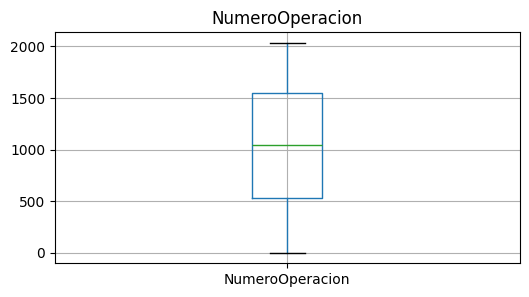

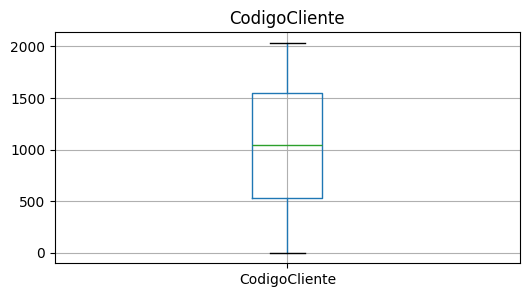

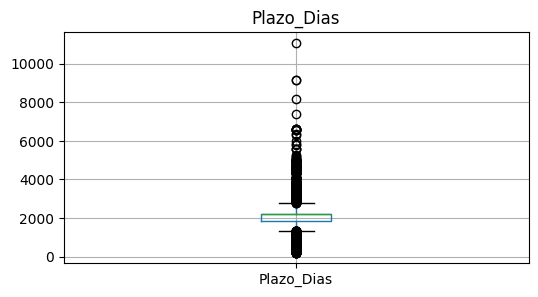

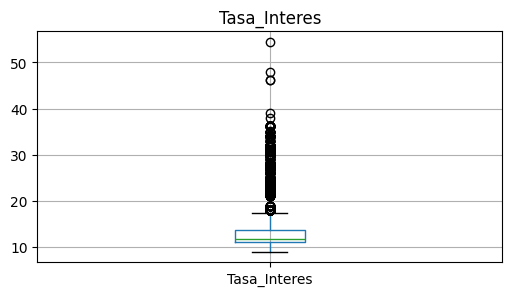

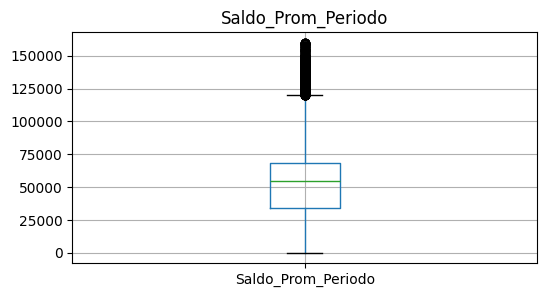

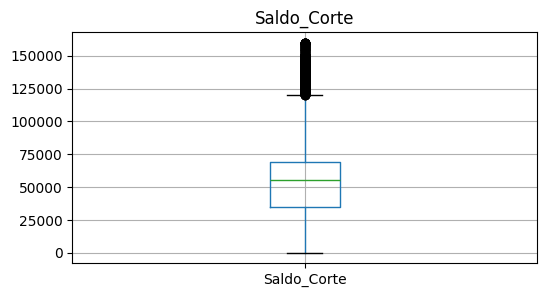

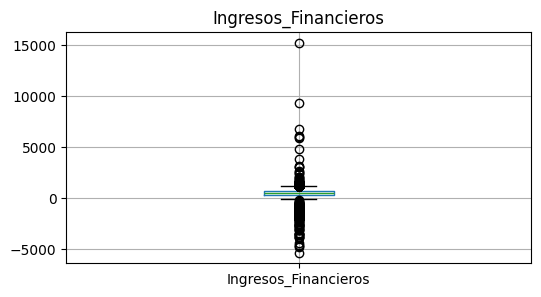

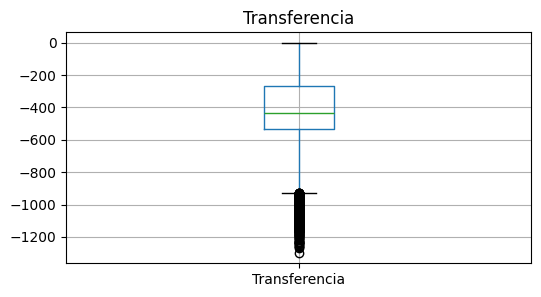

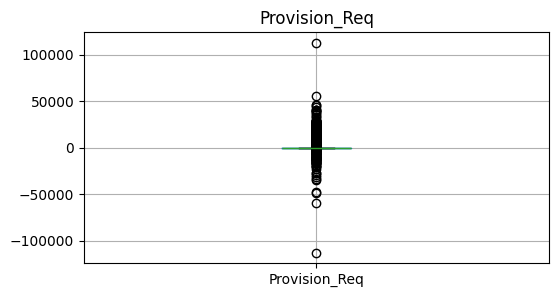

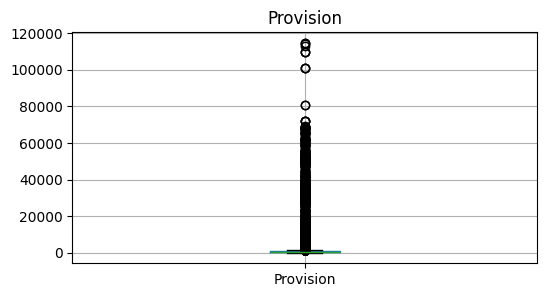

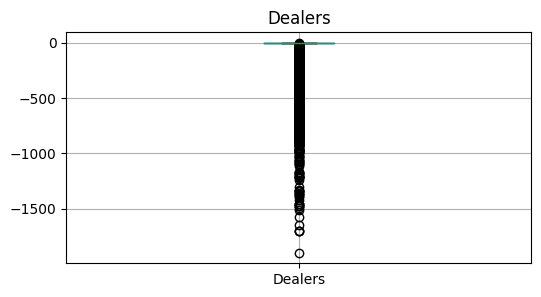

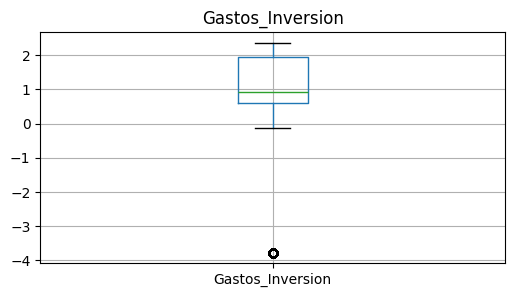

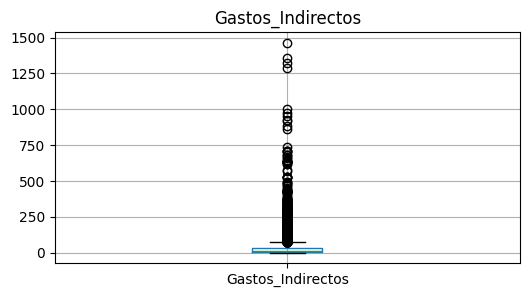

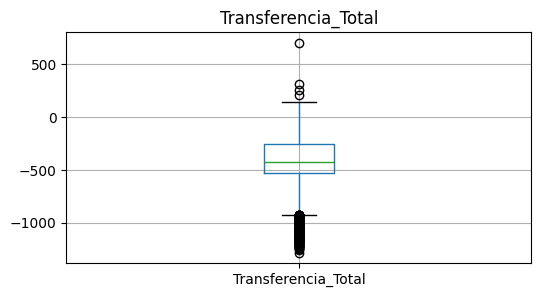

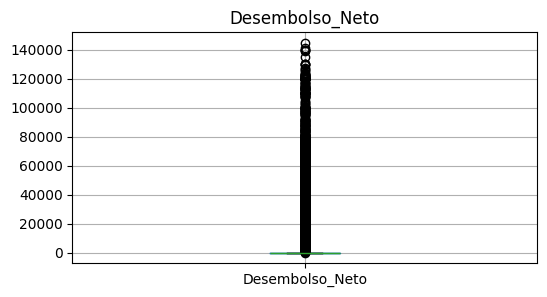

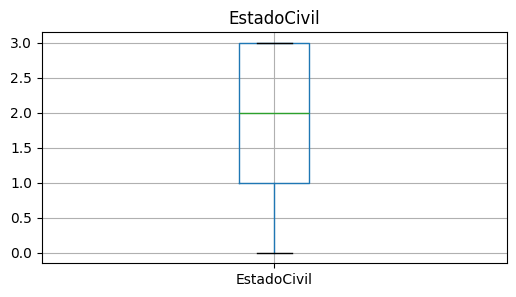

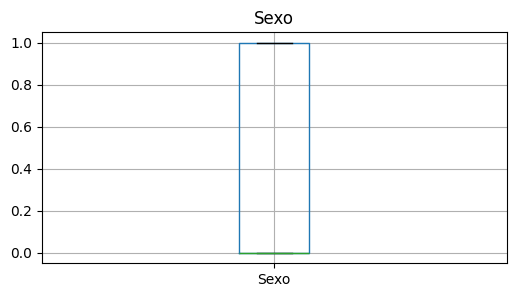

In [ ]:
for col in datos.select_dtypes(include="number").columns:
    plt.figure(figsize=(6,3))
    datos.boxplot(column=col)
    plt.title(col)
    plt.show()

> **Solución: winzorización (variables por variable)**

In [ ]:
datos1 = datos.copy() # una copia de la base original

In [ ]:
datos1["Saldo_Prom_Periodo"] = winsorize(datos1["Saldo_Prom_Periodo"], limits=[0.01, 0.03])

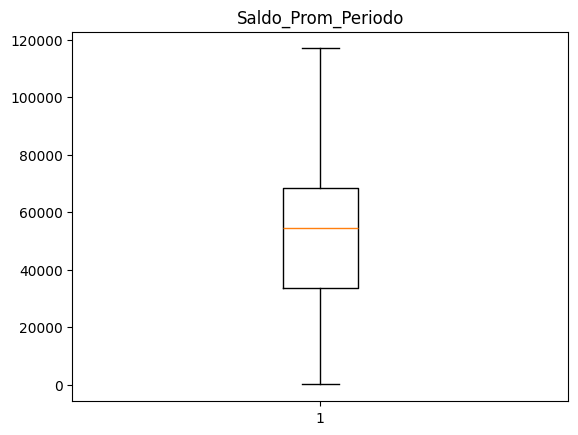

In [ ]:
plt.boxplot(datos1["Saldo_Prom_Periodo"])
plt.title("Saldo_Prom_Periodo")
plt.show()

## **3. Duplicados**

In [ ]:
# Filas completamente duplicadas
datos.duplicated().sum()

np.int64(0)

In [ ]:
# Eliminar duplicados
datos = datos.drop_duplicates()